# How to train your model
---

This notebook trains EmberFlow from scratch on a small catalog of mock stars
so that you can see the full recipe and use it for your own catalog of rotators.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import zuko

from emberflow import EmberFlow
from emberflow.constants import P_OUT, PRIOR_LOGA_MYR, PRIOR_LOGPROT
from emberflow.plots import COLOR, COLOR_ACCENT, LABEL_FS, TICK_FS, set_paper_style

set_paper_style()
rng = np.random.default_rng(0)
torch.manual_seed(0)

## A mock catalog of stars

We uniformly draw ages and masses to create our mock catalog, then sample one rotation period per star from
the released model.

We also give each mock star a fake age uncertainty.

In [2]:
ref = EmberFlow.load()

n = 2000
mass = rng.uniform(0.15, 0.60, n)
age_gyr = 10 ** rng.uniform(np.log10(0.05), np.log10(10.0), n)
mass_err = np.full(n, 0.02)
prot = np.array([ref.sample_prot(age_gyr=a, mass=m, mass_err=e, n=1)[0]
                 for a, m, e in zip(age_gyr, mass, mass_err)])

# lower and upper one-sigma age uncertainties, in dex
loga = np.log10(age_gyr * 1000)
loga_err_lo = rng.uniform(0.10, 0.35, n)
loga_err_hi = rng.uniform(0.10, 0.35, n)

cond = np.column_stack([loga, mass, mass_err]).astype("float32")
x = np.log10(prot).astype("float32").reshape(-1, 1)
print(cond.shape, x.shape)

(2000, 3) (2000, 1)


##  Drawing ages
EmberFlow draws $N_{\rm age}$ ages from each
star's uncertainty and averages the likelihood over them. The lower and upper uncertainties form an asymmetric Gaussian.


In [3]:
N_AGE = 10

# two-piece Gaussian: the lower width applies below the literature age, the upper width above it
z = rng.standard_normal((n, N_AGE))
loga_draws = loga[:, None] + z * np.where(z < 0, loga_err_lo[:, None], loga_err_hi[:, None])
loga_draws = np.clip(loga_draws, *PRIOR_LOGA_MYR)

# (n, N_AGE, 3): only the age column varies across draws
cond_draws = np.repeat(cond[:, None, :], N_AGE, axis=1)
cond_draws[:, :, 0] = loga_draws
print(cond_draws.shape)

(2000, 10, 3)


## Build and train the flow

The architecture is a neural spline flow with a single observable ($\log P_{\mathrm{rot}}$)
conditioned on three inputs.

Each star's flow log likelihood is averaged over $N_{\rm age}$ ages:

$$\bar{\ell}_i = \frac{1}{N_{\rm age}} \sum_{s=1}^{N_{\rm age}}
  \log p_\theta\!\left(y_i \mid \log_{10}\tau_i^{(s)}, x_i\right),$$

where $y_i = \log_{10} P_{\mathrm{rot},i}$ and $x_i = (M_{\star,i}, \sigma_{M,i})$

The final loss is:

$$\mathcal{L}(\theta) = -\frac{1}{B} \sum_{i=1}^{B}
  \log\!\left[(1 - f_{\rm out})\,e^{\bar{\ell}_i} + f_{\rm out}\,p_{\rm out}(y_i)\right]$$

with $f_{\rm out} = 0.05$ and $p_{\rm out}$ is a uniform distribution.

In [4]:
mean = cond.mean(0)
std = cond.std(0)
C = torch.tensor((cond_draws - mean) / std)   # (n, N_AGE, 3)
X = torch.tensor(x)                           # (n, 1)

flow = zuko.flows.NSF(1, 3, transforms=3, hidden_features=(64, 64, 64, 64))

BATCH = 32
STEPS = 10_000

# oneCycleLR scheduler
opt = torch.optim.Adam(flow.parameters(), lr=1e-5)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, total_steps=STEPS,
                                            pct_start=0.1, div_factor=100)

ln_wf = float(np.log(1 - P_OUT))
ln_pout = float(np.log(P_OUT / (PRIOR_LOGPROT[1] - PRIOR_LOGPROT[0])))

losses = []
perm, cursor = torch.randperm(len(X)), 0
for step in range(STEPS):
    if cursor + BATCH > len(X):        # reshuffle
        perm, cursor = torch.randperm(len(X)), 0
    idx = perm[cursor:cursor + BATCH]
    cursor += BATCH
    b = len(idx)

    # evaluate every (star, drawn age) pair  then average over
    #  N_AGE draws so each star contributes one log likelihood
    log_flow = flow(C[idx].reshape(b * N_AGE, 3)).log_prob(
        X[idx].repeat_interleave(N_AGE, dim=0))
    ell = log_flow.reshape(b, N_AGE).mean(1)
    log_mix = torch.logaddexp(ln_wf + ell,
                              torch.full_like(ell, ln_pout))
    loss = -log_mix.mean()

    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()
    losses.append(loss.item())

flow.eval()

NSF(
  (transform): LazyComposedTransform(
    (0-2): 3 x ElementWiseTransform(
      (base): MonotonicRQSTransform(bins=8)
      (hyper): MLP(
        (0): Linear(in_features=3, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): ReLU()
        (6): Linear(in_features=64, out_features=64, bias=True)
        (7): ReLU()
        (8): Linear(in_features=64, out_features=23, bias=True)
      )
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
)

## Using the trained model

The trained flow works with the `EmberFlow` API, so we can use its functions for convenience.

In [5]:
card = {
    "cond_cols": ["log_age_myr", "mass_msun", "mass_msun_err_avg"],
    "transforms": 3,
    "hidden_features": [64, 64, 64, 64],
    "training_range": {
        "mass_msun": [float(mass.min()), float(mass.max())],
        "prot_days": [float(prot.min()), float(prot.max())],
        "age_gyr": [float(age_gyr.min()), float(age_gyr.max())],
    },
}
model = EmberFlow(flow, mean, std, card)

post = model.age_posterior(prot=25.0, mass=0.45, mass_err=0.02)
print(post)

AgePosterior(2.38 -1.49/+4.76 Gyr, 68%)


Let's see how well the learned density of this new model compares with the simulated periods (which came from the released model's learned density).

Text(0.5, 1.0, '$M_\\star$ = 0.50 $M_\\odot$,  age = 1 Gyr')

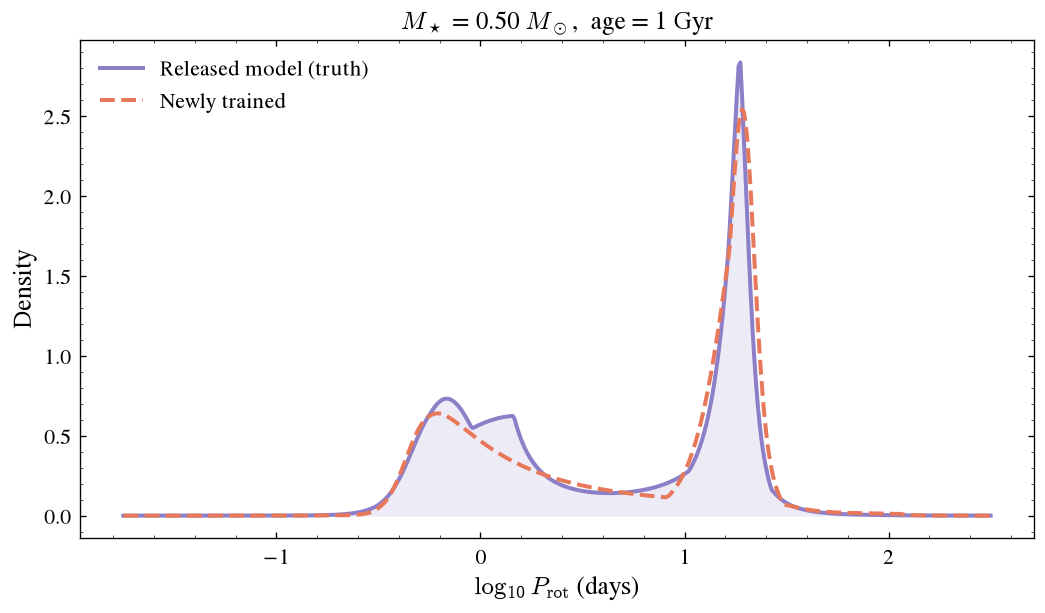

In [6]:
grid, pdf_new = model.prot_density(age_gyr=1.0, mass=0.50, mass_err=0.02)
_, pdf_ref = ref.prot_density(age_gyr=1.0, mass=0.50, mass_err=0.02)

fig, ax = plt.subplots(figsize=(8.6, 5.0), layout="constrained")
ax.fill_between(grid, pdf_ref, color=COLOR, alpha=0.15)
ax.plot(grid, pdf_ref, color=COLOR, lw=2.4, label="Released model (truth)")
ax.plot(grid, pdf_new, color=COLOR_ACCENT, lw=2.4, ls="--", label="Newly trained")
ax.set_xlabel(r"$\log_{10} P_{\rm rot}$ (days)", fontsize=LABEL_FS)
ax.set_ylabel("Density", fontsize=LABEL_FS)
ax.tick_params(labelsize=TICK_FS)
ax.legend(frameon=False, fontsize=TICK_FS)
ax.set_title(r"$M_\star$ = 0.50 $M_\odot$,  age = 1 Gyr", fontsize=LABEL_FS)